## Modulo 5: Minería de Datos y Modelos Ocultos de Markov





#**Ejercicio 1**

**Ejercicio 1a**

En primer lugar necesitará instalar algunos programas. Éstos son MAFFT, para el MSA, y HMMER para generar HMMs y realizar minería de datos.

In [ ]:
#sudo apt-get install mafft
#sudo apt-get install hmmer


**Ejercicio 1b y c**

En primer lugar necesitará instalar algunos programas. Éstos son MAFFT, para el MSA, y HMMER para generar HMMs y realizar minería de datos.

In [ ]:
#mafft PF11563_seed.txt > pf11563_seed_msa.fasta

**Ejercicio 1d**

Corra todos los comandos anteriores y analice un poco el archivo “secuencias_modelo.hmm”, puede identificar en él los parámetros que usted conoce debe poseer el modelo (probabilidad de emisión de cada residuo en cada columna (estado match), columnas importantes, probabilidad de inserción, etc).

In [ ]:
#hmmbuild protoglobin_modelo.hmm pf11563_seed_msa.fasta

El archivo devuelve un formato tipo tabla que expresa en orden el -log(probabilidad) emision, insercion, transicion.


**Ejercicio 1e**

Analice un poco el archivo de salida de HMMsearch, trate de identificar dónde están los resultados obtenidos para cada secuencia query, y de ellos donde esta el E-value, la cobertura, etc

In [ ]:
hmmsearch secuencias_modelo.hmm secuencias_target.fasta > busqueda.out

Devuelve varios parametros de alineamiento, de los cuales utilizaremos luego el bitscore para determinar un punto de corte.

#Ejercicio 2: Recuperar los dominios con Python

**Ejercicio 2a**

Histograma de puntajes de dominio. El primer objetivo busca Implementar un script en python que grafique un histograma de puntajes de secuencia POR DOMINIO (recuerde, usted le interesa recuperar los dominios globina, no la secuencia entera de cada proteína), a partir de la salida de hmmsearch. Necesitará una librería para graficar cómo matplotlib y la librería de biopython SearchIO, para poder parsear el archivo salida de hmmsearch.

In [ ]:
!pip install biopython

     |████████████████████████████████| 2.3MB 7.3MB/s 


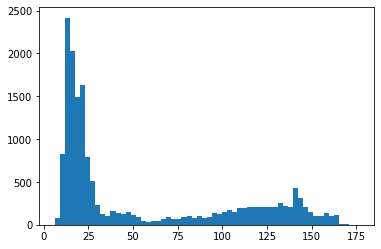

In [ ]:
from Bio import SearchIO
import matplotlib.pyplot as plt

resultados=list(SearchIO.read('protoglobin_search.out', 'hmmer3-text'))
scores=[]
for hits in resultados:
    for hsp in hits:
        scores.append(hsp.bitscore)

histogram=plt.hist(scores, bins=60)

plt.show()

**2b) Determinación de puntaje de corte y Extracción del archivo de los dominios de interès.**

Desarrolle en python un código que utilice el puntaje de corte recién establecido (esto debe ser un parámetro) para extraer los dominios búscados en las secuencias correspondientes.
El mismo debe devolver un archivo fasta con dichas secuencias recortadas.

El código debe tener ademàs las dos siguientes funciones:  
i) Debe ser capaz de obtener los Uniprot IDs y las posiciones de inicio y fin de los dominios y entregar los resultados como lista de listas (o una matriz de numpy o pandas),
ii) Tomar los valores de la lista anterior (IDs y posiciones), y usarlos para cortar las secuencias del registro fasta original.


In [ ]:
from Bio import SeqIO
import pandas as pd

def extraerPosiciones(resultado_hmmsearch,puntaje_corte):
    puntajes_positivos = []
    uniprotID = []
    start=[]
    end = []

    searchFile=list(SearchIO.read(resultado_hmmsearch, 'hmmer3-text'))
    for hits in searchFile:
        for hsp in hits:
            if hsp.bitscore > puntaje_corte:
                uniprotID.append(hits.id.split("|")[1])
                puntajes_positivos.append(hsp.bitscore)
                start.append(hsp.env_start)
                end.append(hsp.env_end)
    zippedList= list(zip(uniprotID,puntajes_positivos,start,end))
    df = pd.DataFrame(zippedList,columns= ['uniprotID','puntajes_positivos','start','end'])


    return df,uniprotID

In [ ]:
#Colocando el punto de corte en 60
df,uniprotID =extraerPosiciones("protoglobin_search.out",60)
df

,uniprotID,puntajes_positivos,start,end
0,A0A3E0RFZ9,176.5,34,191
1,D3FSA7,171.1,30,186
2,U6SS08,171.1,32,188
3,A0A0K9H8Z2,169.8,30,186
4,G0RZQ1,169.8,17,200
...,...,...,...,...
5643,A0A1C2I839,60.3,3,157
5644,A0A098FF45,60.3,0,76
5645,K9RBV1,60.6,5,160
5646,A0A1R1PNY0,60.3,3,127


Decidimos poner como linea de corte 60 dado que nos parece que es el punto en donde se ve la mayor diferencia entre ambos picos de los histrogramas. No estamos siendo del todo conservadores, y estamos tomando la mayor cantidad de secuencias que podrian ser protoglobinas

Para definir el inicio y fin de cada dominio decidimos utilizar las parámetros de "envelope", la cual es menos conservadora que alignment.

In [ ]:
from Bio.SeqRecord import SeqRecord

def guardarDominios(secuencias_completas, limites,domain_name):
    records= []
    fasta=list(SeqIO.parse(secuencias_completas, 'fasta'))
    count = 1
    for hits in fasta:
            identidad = hits.id.split("|")[1]
            if identidad in limites:
                new_record = SeqRecord(hits.seq, id=identidad+'_'+domain_name+'_'+str(count))
                records.append(new_record)
                count += 1
    SeqIO.write(records, domain_name+"_seqs.fasta", "fasta")
    return records

protoglobin_doms = guardarDominios("globin_full_sequences.fasta",uniprotID,"ProtoGlobin")


**Ejercicio 2c.**


Responda:
¿Cuántos dominios de protoglobina logró recuperar de la minería de datos?
¿Puede afirmar que recuperó todos y que no dejó alguno afuera?
¿O que solo recuperó dominios protoglobina y que no incorporó dominios globina de otro tipo? ¿Por qué?


In [ ]:
print(len(protoglobin_doms))

5648


Se encontraron 5648 dominios, no se puede afirmar que se hayan encontrado todos, se utilizo una linea de corte visual a partir del histograma, por lo que puede haber falsos positivos o negativos.
Hasta este punto no se puede afirmar que haya incorporado otros dominios globina, pero se discutira mas adelante con los resultados del ejercicio 3.

# **Ejercicio 3: comparar y analizar alineamientos**


**3a) Alinear los dominios.**


Ahora lo que vamos a hacer es utilizar HMMer para alinear y comparar con el alineamiento que haga MAFFT.
El comando para correr hmmalign es del tipo:

hmmalign -o alin_seqs.sto secuencias_modelo.hmm dominios.fasta

El comando para alinear con MAFFT ya lo conoce!

**Ejercicio 3a)**

Parsee los MSAs hechos con hmmalign y MAFFT y busque la posición de la histidina F8 (el residuo más conservado y característico de todas las globinas), y calcule la proporción de gaps en el MSA para esa posición.  (sugerencia: busque una columna en el MSA donde la histidina representa más del 80% de los aminoácidos presentes en esa columna).

In [ ]:
#Alineamiento con hmmaling
#hmmalign -o protoglobin_domain_alin_seqs.sto protoglobin_modelo.hmm Protoglobin_seqs.fasta


In [ ]:
from Bio import AlignIO
import pandas as pd

def columnas_conservadas(aac,prop,archivo, formato):
    aac = str(aac)
    align = AlignIO.read(archivo,formato)
    align_pd=pd.DataFrame(align)  #convierte el alineamiento en un pandas dataframe
    #align_pd
    filas = align_pd.shape[0]
    columnas = align_pd.shape[1]
    lista_columnas_conservadas = []
    results = {}
    for i in range (columnas):
        counts = align_pd[i].value_counts()
        lista_elem = counts.index   #devuelve lista con los elementos que hay en esa columna k

        if aac in lista_elem:
            cantidad_veces = counts[aac]
            #cantidad_guiones = align_pd[i].value_counts()["-"]
            if (cantidad_veces/filas)> prop and cantidad_veces > 1 :
                #lista_columnas_conservadas.append(i)
                results[i] = {aac:cantidad_veces,"Fracción_"+aac:(cantidad_veces/filas),"Gaps":counts["-"],"Fracción_Gaps":counts["-"]/filas,"Total_Seq":filas}
                #print(("porcentaje H: " + str(cantidad_veces/numero_total)*100))
                #print(("guiones: " + str(cantidad_veces/numero_total)*100))
    return pd.DataFrame(results)

In [ ]:
columnas_conservadas("H",0.8, "protoglobin_domain_alin_seqs.sto", "stockholm")

,632
Fracción_Gaps,0.000708
Fracción_H,0.929001
Gaps,4.000000
H,5247.000000
Total_Seq,5648.000000


In [ ]:
#Alineamiento con mafft
#mafft Protoglobin_dominios.fasta > protoglobin_domain_mafft.fasta
columnas_conservadas("H",0.8,"protoglobin_domain_mafft.fasta", "fasta")

,2298
Fracción_Gaps,0.002479
Fracción_H,0.929178
Gaps,14.000000
H,5248.000000
Total_Seq,5648.000000


Compare el porcentaje de histidinas en esa columna entre los dos MSAs obtenidos (por MAFFT y hmmalign), y la proporción de gaps obtenida.

Los porcentajes son extremadamente similares (92,90% vs 92,91%).

¿En qué posición está la histidina F8 en cada MSA? ¿Está en la misma posición en ambos casos?
No, n el alineamiento hecho por HMMer está en la posición 632, y en el realizado por MAFFT está en la posición 2298.

¿En cuál MSA hay más presencia de gaps? Hay una mayor proporción de Gaps al alinear con MAFFT


**3 b) Minería de datos.**



1) Descargue los seeds de las éstas dos familias de globinas en Pfam, genere los HMM y corra hmmsearch con cada HMM nuevo contra el set de globinas.

In [ ]:
# !mafft globin_seed.txt > seed_msa_globin.fasta
# !mafft bac_globin_seed.txt > seed_msa_bac_globin.fasta

2) Genere los histogramas de puntaje de dominio y establezca un umbral de corte para luego extraer los dominios.

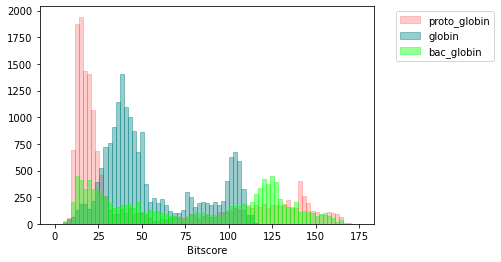

In [ ]:
# !hmmbuild seed_modelo_globin.hmm seed_msa_globin.fasta #genero seed hmm para globin
# !hmmsearch seed_modelo_globin.hmm globin_full_sequences.fasta > busqueda_glob.out #hago la busqueda y el output para globin

# !hmmbuild seed_modelo_bac_globin.hmm seed_msa_bac_globin.fasta #genero seed hmm para bac_globin
# !hmmsearch seed_modelo_bac_globin.hmm globin_full_sequences.fasta > busqueda_bac_glob.out #hago la busqueda y el output para bac_globin

from Bio import SearchIO
import matplotlib.pyplot as plt

resultados = list(SearchIO.read('protoglobin_search.out', 'hmmer3-text')) #extraigo el score para proto_globin
puntajes_lista1 = []
for seq in resultados:
    for domain in seq:
        puntajes_lista1.append(domain.bitscore)

resultados_glob = list(SearchIO.read('globin_search.out', 'hmmer3-text'))#extraigo el score para globin
puntajes_lista2 = []
for seq in resultados_glob:
    for domain in seq:
        puntajes_lista2.append(domain.bitscore)

resultados_bac_glob = list(SearchIO.read('bacglobin_search.out', 'hmmer3-text')) #extraigo el score para bac_globin
puntajes_lista3 = []
for seq in resultados_bac_glob:
    for domain in seq:
        puntajes_lista3.append(domain.bitscore)

plt.hist(puntajes_lista1, bins = 75, label = "proto_globin", alpha = 0.2, edgecolor = "red", color = "red",range=(0,175)) #grafico proto
plt.hist(puntajes_lista2, bins = 75, label = "globin", alpha = 0.4, edgecolor = "teal", color = "teal",range=(0,175) ) #grafico globin
plt.hist(puntajes_lista3, bins = 75, label = "bac_globin", alpha = 0.4, edgecolor = "lime", color = "lime",range=(0,175)) #grafico bac
plt.xlabel("Bitscore")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show() #muestro el histograma

3) Compare los 3 sets obtenidos. Hay alguna secuencia presente en más de un set? (use los Uniprot ID de las secuencias)

In [ ]:
from Bio import SearchIO
from collections import defaultdict

FASTAdict = defaultdict(str)
with open('globin_full_sequences.fasta') as fastaList: #abro mi base de datos
    for line in fastaList: # la recorro
        if line[0] == '>': # si es header/description
            key = line.strip('\n').split("|")[1] # guardo el identificador de uniprot como key
        else:
            FASTAdict[key] += line.strip('\n') # sino, es la secuencia, y me la guardo como value
fastaList.close() #cierro el archivo de la base de datos

def extraerPosiciones2(puntaje_corte, archivo_input):
    limit_dic = {} #armo diccionario en vez de lista
    searchFile=list(SearchIO.read(archivo_input, 'hmmer3-text'))
    for seq in searchFile: # itero sobre los hits
        for domain in seq: # itero sobre los hsp
            key = seq.id.split('|')[1] #extraigo el uniprot ID
            if domain.bitscore >= puntaje_corte: # me fijo que el score supere el umbral
                limit_dic.setdefault(key,[]).append((domain.env_start, domain.env_end)) # guardo el ID con su tupla correspondiente (acepta multiples tuplas por ID)
    return limit_dic

def devolverSecuencias2(puntaje_corte, archivo_input):
    limit_dic = extraerPosiciones2(puntaje_corte, archivo_input)
    filtered_list = []
    searchFile=list(SearchIO.read(archivo_input, 'hmmer3-text')) # sobre el resultado de la búsqueda de motivos en mi base de datos FALTA FILTRAR
    for seq in searchFile: # recorro los hits
        for domain in seq: # recorro los hsps
            key = seq.id.split('|')[1] # uniprotID del hit
            if key in limit_dic: #si el key está en el diccionario que pasó el filtrado
                for interval in range(len(limit_dic[key])): #para cada intervalo
                    filtered_list.append(seq.id + str(interval)) #FASTAdict[key][interval[0]:interval[1]]) #guarda el ID + descripcion + región que coincide con el limit_dic de ese hit en el output
    return filtered_list

#extraer listas de secuencias
list_proto = devolverSecuencias2(60, 'protoglobin_search.out') # list de seqs en proto_globin
list_globin = devolverSecuencias2(70, 'globin_search.out') # list de seqs en  globin
list_bac = devolverSecuencias2(90, 'bacglobin_search.out') # list de seqs en bac_globin

#comparar 1vs1 entre los 3 y guardarme los que aparezcan en más de una de las listas
shared_seqs_proto_globin = list(set(list_proto).intersection(list_globin)) #lista de IDS compartidos
shared_seqs_proto_bac = list(set(list_proto).intersection(list_bac)) #lista de IDS compartidos
shared_seqs_globin_bac = list(set(list_globin).intersection(list_bac)) #lista de IDS compartidos

print(len(shared_seqs_globin_bac)) #vacío
print(len(shared_seqs_proto_bac)) #vacío
print(len(shared_seqs_proto_globin)) #vacío

0
0
0


No se observan dominios compartidos, entre las familias con los puntos de corte establecidos, según el criterio decidido a partir de los histogramas anteriores. Incluso con cutoffs muy bajos, como por ejemplo 50 para los 3 casos, se mantiene que no hay prácticamente intersección entre los distintos grupos. Se observa únicamente 1 dominio compartido entre protoglobinas y las bac globinas.

4) Corra cada HMM contra cada set de dominios obtenidos (si son 3 HMM y 3 sets de dominios recuperados, son un total de 9 corridas de hmmsearch).

In [ ]:
df,uniprotID =extraerPosiciones("globin_search.out",70)
globin_doms = guardarDominios("globin_full_sequences.fasta",uniprotID,"Globin")

df,uniprotID =extraerPosiciones("bacglobin_search.out",85)
bacglobin_doms = guardarDominios("globin_full_sequences.fasta",uniprotID,"BacGlobin")

#hmmsearch bacglobin_modelo.hmm Globin_seqs.fasta > bacglobin_vs_Globin_search.out
#hmmsearch bacglobin_modelo.hmm ProtoGlobin_seqs.fasta > bacglobin_vs_ProtoGlobin_search.out
#hmmsearch bacglobin_modelo.hmm BacGlobin_seqs.fasta > bacglobin_vs_BacGlobin_search.out
#hmmsearch globin_modelo.hmm Globin_seqs.fasta > globin_vs_Globin_search.out
#hmmsearch globin_modelo.hmm ProtoGlobin_seqs.fasta > globin_vs_ProtoGlobin_search.out
#hmmsearch globin_modelo.hmm BacGlobin_seqs.fasta > globin_vs_BacGlobin_search.out
#hmmsearch protoglobin_modelo.hmm Globin_seqs.fasta > protoglobin_vs_Globin_search.out
#hmmsearch protoglobin_modelo.hmm ProtoGlobin_seqs.fasta > protoglobin_vs_ProtoGlobin_search.out
#hmmsearch protoglobin_modelo.hmm BacGlobin_seqs.fasta > protoglobin_vs_BacGlobin_search.out

5) Usando los resultados de búsqueda de 4) genere histogramas de distribución de puntaje para cada HMM (para cada set de secuencias use un color distinto)


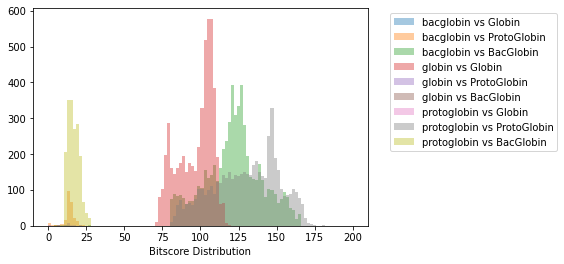

In [ ]:
from Bio import SearchIO
import matplotlib.pyplot as plt
%matplotlib inline


resultados_ = ["bacglobin_vs_Globin_search.out", "bacglobin_vs_ProtoGlobin_search.out", "bacglobin_vs_BacGlobin_search.out", "globin_vs_Globin_search.out" ,  "globin_vs_ProtoGlobin_search.out" , "globin_vs_BacGlobin_search.out", "protoglobin_vs_Globin_search.out" , "protoglobin_vs_ProtoGlobin_search.out" ,"protoglobin_vs_BacGlobin_search.out" ]

for resultado in resultados_:
    hits = list(SearchIO.read(resultado, 'hmmer3-text'))

    puntajes=[]
    name = resultado.split("_")
    name = (" ").join(name[0:3])

    for match in hits:
        for hsps in match.hsps:
            puntajes.append(hsps.bitscore)
    plt.hist(puntajes, alpha= 0.4, bins=100, label = name, range=(0,200))

plt.xlabel("Bitscore Distribution")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')